# Distribuciones

La distribución de probabilidad es un mapa o un retrato hablado de todos los resultados posibles de ese fenómeno. Pero no es un retrato cualquiera: es un retrato que nos dice dónde se concentra mayormente la probabilidad ("masa").

#### Pregunta: ¿De que forma entran los gatos a las cajas?

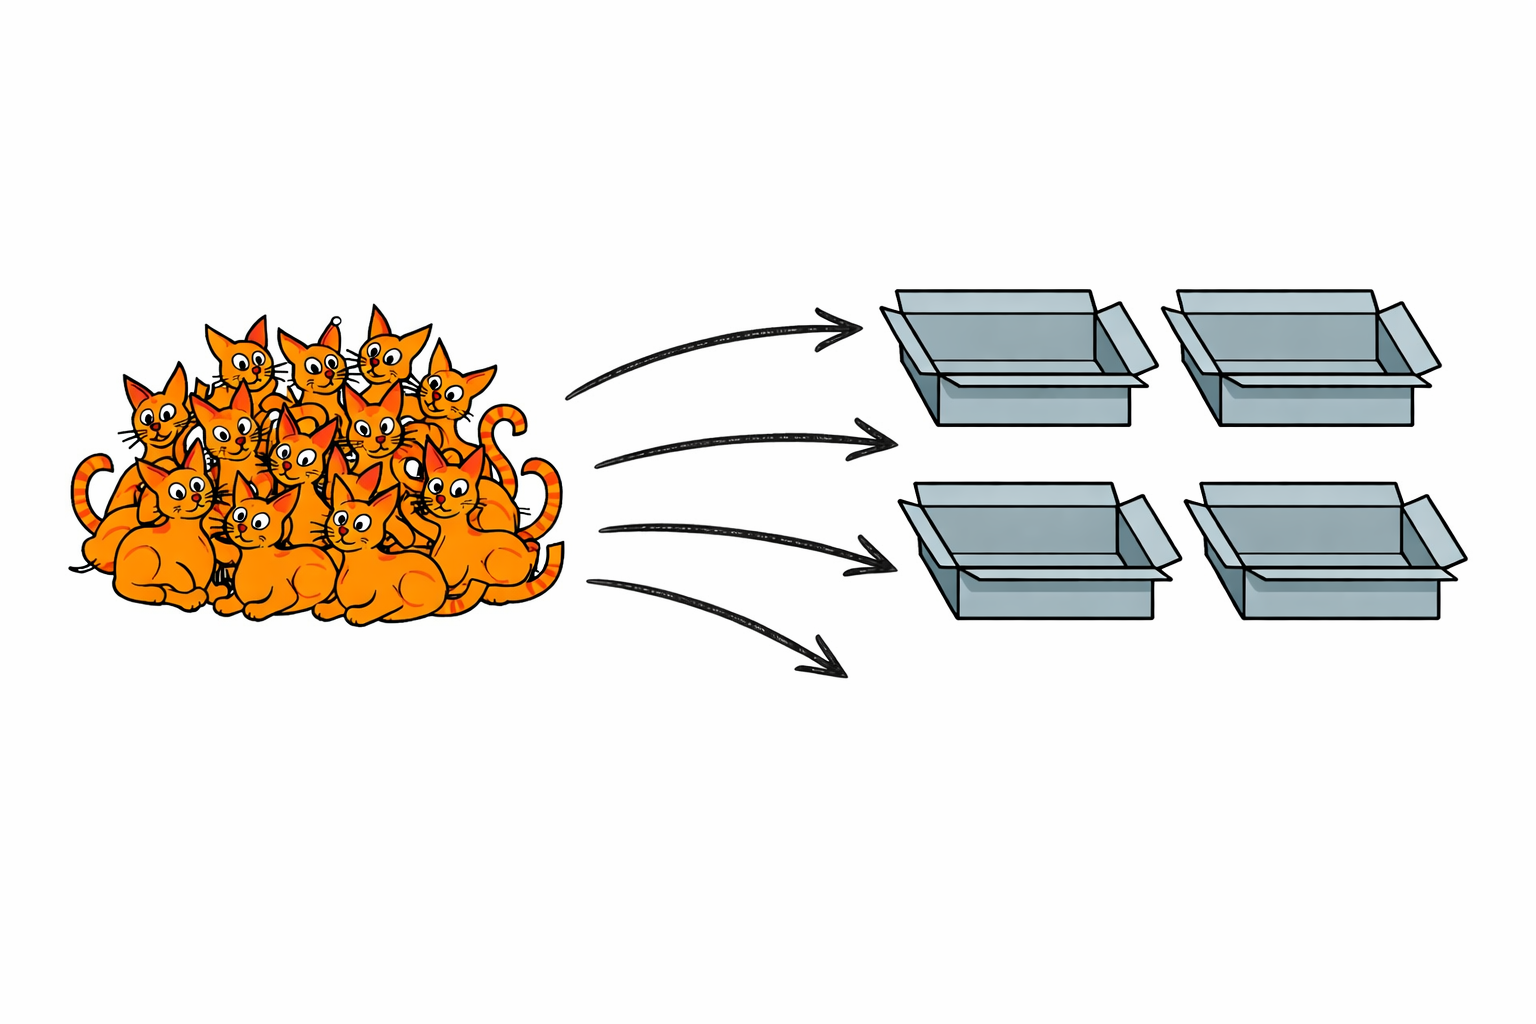

La distribución te dice $\textbf{"la probabilidad de que el resultado caiga dentro de un rango de valores".}$ Con nuestro grupo de gatos, la probabilidad de que caigan en una caja concreta.

# Distribución de Bose-Einstein

Imaginemos que tenemos $N$ gatos idénticos y $g$ cajas distintas y se quieren distribuir los gatos en las cajas.

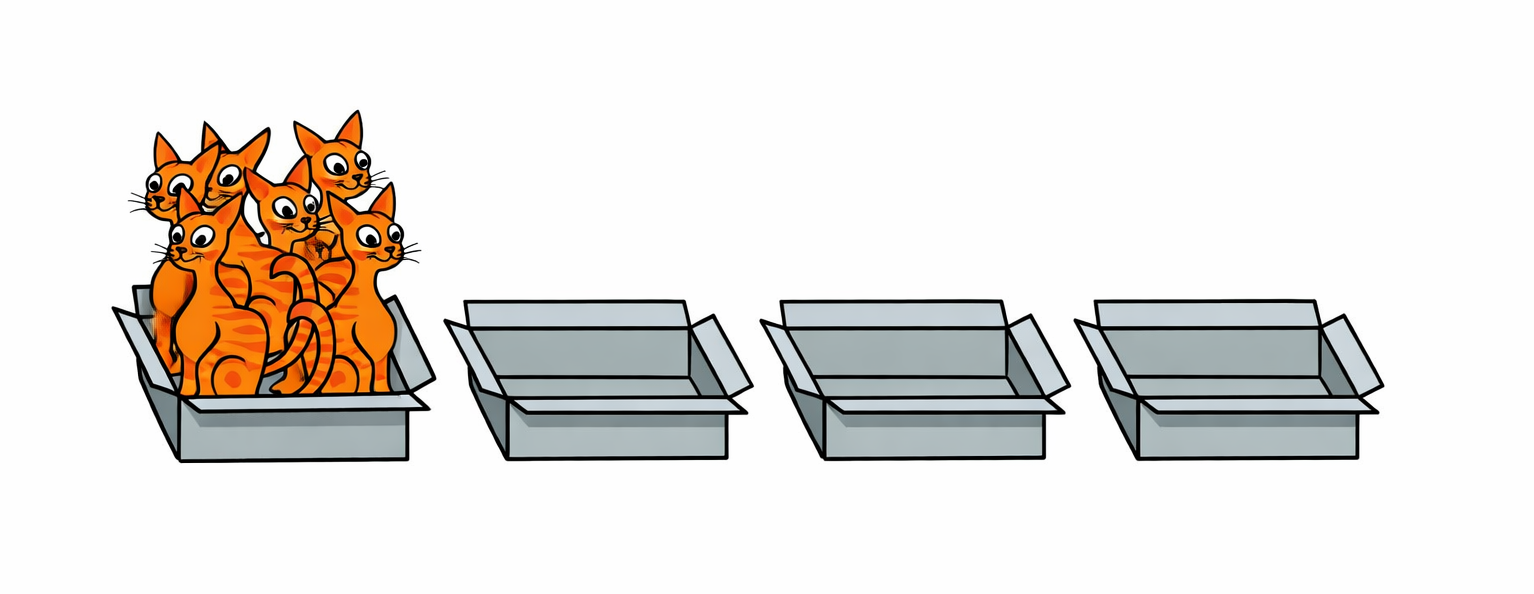

La intuición es:

- Hay “cajas” o “niveles” donde pueden estar los Bose-Cats,

- Los gatos son indistinguibles,

- No hay restricción de un gato por estado, por eso puede haber acumulación en un mismo estado.

Ejemplo:
Si tenemos 3 Bose-cats y 2 cajas, las configuraciones posibles son

$$
(3,0), \quad(2,1), \quad(1,2), \quad(0,3)
$$

Donde cada par indica cuántos gatos hay en cada caja.

$\textbf{No se trata de "física cuántica difícil"}$, sino de una ley de probabilidad sobre ocupaciones.


$$\textbf{\large ¿Cuál es la probabilidad de que una cierta caja tenga ocupación $n$ ?}$$

La ocupación media Bose-Einstein es

$$
\left\langle n_i\right\rangle=\frac{1}{e^{\left(\epsilon_i-\mu\right) /(k T)}-1}
$$

Donde:
- $\epsilon_i$ es la energía del estado o caja $i$
- T: temperatura (a baja temperatura, los estados de menor energía concentran más ocupación y a mayor temperatura, la distribución se vuelve más extendida.)
- k: constante de Boltzmann
- $\mu$ : potencial químico
- $\left\langle n_i\right\rangle$ : número promedio de partículas en ese estado

En otras palabras
- Cada estado tiene un "costo" o energía $\epsilon_i$,
- Los estados de menor energía tienden a ocuparse más,
- La temperatura controla qué tan dispersa está la distribución,
- La fórmula da la ocupación promedio esperada de cada estado.

$$ \textbf{\large Viendolo más probabilistico...}$$

Tenemos una variable aleatoria “número de partículas en el estado i”, Bose–Einstein nos dice cómo se comporta su valor esperado. Agregando que los estados de baja energía tienen más probabilidad de presentar ocupaciones altas por parte de los gatos.

$$\textbf{ \large En Bose–Einstein, la acumulación no está penalizada; al contrario, varios Bose-cats pueden compartir el mismo estado.}$$

### Problema computacional

Dado un conjunto de cajas $\epsilon_i$, calcular la ocupación promedio Bose-Einstein de cada estado.

$\textbf{Pensemos...}$

Entradas o parámetros
- lista
- temperatura $T$
- potencial químico $\mu$
- constante $k$

Salida
- lista de ocupaciones promedio $\left\langle n_i\right\rangle$

$\text{Construimos los pasos del algoritmo}:$

1. Recorrer cada caja $\epsilon_i$,
2. Calcular

$$
x_i=\frac{\epsilon_i-\mu}{k T}
$$

3. Evaluar

$$
n_i=\frac{1}{e^{x_i}-1}
$$

4. Guardar $n_i$,
5. Repetir para todas las cajas o estados.

### Pseudo código

leer lista_cajas
leer T, mu, k

crear lista_ocupaciones vacía

para cada energia e en lista_cajas:
    x = (e - mu) / (k*T)
    n = 1 / (exp(x) - 1)
    guardar n en lista_ocupaciones

mostrar lista_ocupaciones

### Versión base

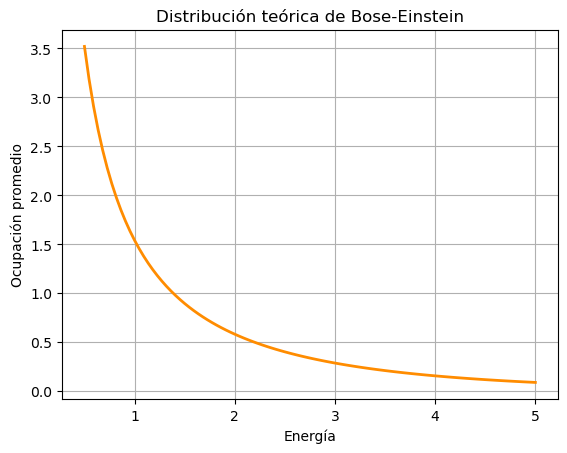

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def bose_einstein(cajas, T, mu=0.0, k=1.0):
    ocupaciones = []
    
    for e in cajas:
        x = (e - mu) / (k * T)
        n = 1 / (np.exp(x) - 1)
        ocupaciones.append(n)
    
    return np.array(ocupaciones)

# Parámetros
cajas = np.linspace(0.5, 5, 100)
T = 2.0
mu = 0.0

ocupaciones = bose_einstein(cajas, T, mu)

plt.plot(cajas, ocupaciones, c ="darkorange", lw=2)
plt.xlabel("Energía")
plt.ylabel("Ocupación promedio")
plt.title("Distribución teórica de Bose-Einstein")
plt.grid(True)
plt.show()

$$\large \text{No estamos simulando partícula por partícula; estamos calculando la ocupación promedio teórica, evaluando la fórmula}$$

## Pesos Bose-E

Resumiendo el método: Primero asignamos a cada "caja" o nivel un peso que mide qué tan atractivo es para una gato estar ahí. Ese peso lo tomamos de la expresión de Bose–Einstein. Después normalizamos los pesos para convertirlos en probabilidades. Finalmente, usamos esas probabilidades para colocar a los Bose-cats aleatoriamente en los niveles.

### Pseudo código

Parametros: cajas, T, mu, k, lista de valores N

Para cada caja i:
       calcular peso_i = 1 / (exp((caja_i - mu)/(k*T)) - 1)

 Normalizar los pesos:
       prob_i = peso_i / suma_de_todos_los_pesos

Para cada valor N:
       iniciar ocupaciones en cero

       repetir N veces:
           elegir una caja al azar con probabilidades prob_i
           sumar 1 a la ocupación de esa caja

       calcular frecuencia_simulada_i = ocupacion_i / N

       calcular error_global(N) =
           promedio de |frecuencia_simulada_i - prob_i|

       guardar error_global(N)

Hacer una simulación final con N grande:
       obtener ocupaciones finales
       obtener frecuencias simuladas finales

Gráfica de probabilidades teóricas vs simuladas
Gráfica de ocupaciones simulada
Gráfica de error global vs N

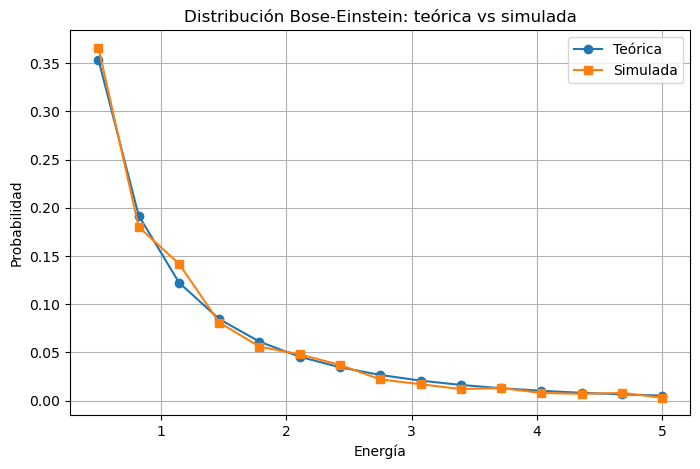

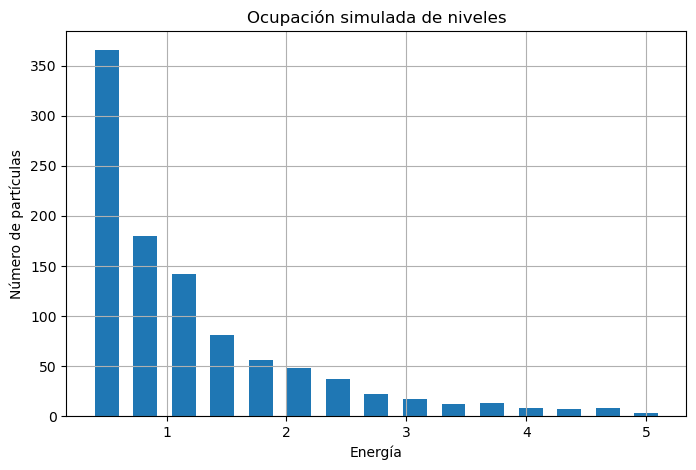

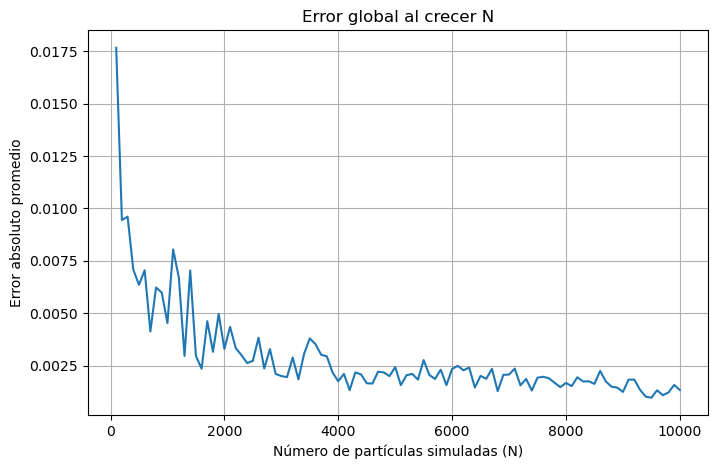

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def bose_pesos(cajas, T, mu=0.0, k=1.0):
    pesos = 1 / (np.exp((cajas - mu) / (k * T)) - 1)
    return pesos

def simular_bose(N_cats, cajas, T, mu=0.0, k=1.0):
    pesos = bose_pesos(cajas, T, mu, k)
    probabilidades = pesos / np.sum(pesos)

    ocupaciones = np.zeros(len(cajas), dtype=int)

    niveles_elegidos = np.random.choice(
        np.arange(len(cajas)),
        size=N_cats,
        p=probabilidades
    )

    for nivel in niveles_elegidos:
        ocupaciones[nivel] += 1

    return probabilidades, ocupaciones

# Parámetros
cajas = np.linspace(0.5, 5.0, 15)
T = 1.5
mu = 0.0

#Err al crecer N 
Ns = range(100, 10001, 100)
errores = []

for N_cats in Ns:
    probabilidades, ocupaciones = simular_bose(N_cats, cajas, T, mu)

    # Frecuencia simulada
    frecuencia_simulada = ocupaciones / N_cats

    # Error absoluto promedio
    error_global = np.mean(np.abs(frecuencia_simulada - probabilidades))
    errores.append(error_global)

N_final = 1000
probabilidades, ocupaciones = simular_bose(N_final, cajas, T, mu)
frecuencia_simulada = ocupaciones / N_final

# Gráfica 1: distribución teórica vs simulada
plt.figure(figsize=(8, 5))
plt.plot(cajas, probabilidades, marker='o', label='Teórica')
plt.plot(cajas, frecuencia_simulada, marker='s', label='Simulada')
plt.xlabel("Energía")
plt.ylabel("Probabilidad")
plt.title("Distribución Bose-Einstein: teórica vs simulada")
plt.grid(True)
plt.legend()
plt.show()

# Gráfica 2: histograma / barras de ocupación simulada
plt.figure(figsize=(8, 5))
plt.bar(cajas, ocupaciones, width=0.2)
plt.xlabel("Energía")
plt.ylabel("Número de partículas")
plt.title("Ocupación simulada de niveles")
plt.grid(True)
plt.show()

# Gráfica 3: error global al crecer N
plt.figure(figsize=(8, 5))
plt.plot(list(Ns), errores)
plt.xlabel("Número de partículas simuladas (N)")
plt.ylabel("Error absoluto promedio")
plt.title("Error global al crecer N")
plt.grid(True)
plt.show()

Aquí usamos:

$$
E(N)=\frac{1}{M} \sum_{i=1}^M\left|p_i^{\text {sim }}-p_i^{\text {teo }}\right|
$$

donde:
- $M$ es el número de niveles,
- $p_i^{\text {sim }}$ es la frecuencia simulada,
- $p_i^{\text {teo }}$ es la probabilidad teórica.

## Monte Carlo B-E

Cuando hablamos de bosones la realidad es que los gatos tienden a irse a la caja "base"

En lugar de colocar directamente los gatos según una probabilidad fija, ahora empezamos con todos los gatos en la caja base o nivel más bajo. Luego dejamos evolucionar el sistema mediante Monte Carlo durante muchos pasos y proponemos movimientos aleatorios entre cajas. Si el movimiento baja la energía, lo aceptamos; si la sube, lo aceptamos solo con cierta probabilidad. Después de muchos pasos, observamos cómo quedaron distribuidos los gatos y comparamos con la distribución teórica.

Para calcular el cambio entre cajas (niveles de energía)

$$
\Delta E=\epsilon_j-\epsilon_i
$$

Y aceptamos el movimiento con regla de Metropolis:
- si $\Delta E\leq 0$, se acepta;
- si $\Delta E>0$, se acepta con probabilidad

$$
e^{-\Delta E /(k T)}
$$

### Pseudo código

Calcular distribución teórica Bose normalizada

Para cada valor N:
    colocar todas las partículas en el nivel más bajo

    repetir varios pasos Monte Carlo:
        elegir un nivel ocupado como origen
        elegir otro nivel como destino
        calcular cambio de energía

        si baja energía:
            aceptar movimiento
        si sube energía:
            aceptar con cierta probabilidad

        si se acepta:
            mover una partícula

    convertir ocupaciones finales en probabilidades simuladas
    calcular error global respecto a la distribución teórica
    guardar error

Hacer una simulación final con N grande

Grafica teoría vs simulación
Grafica histograma de ocupaciones
Grafica error al crecer N

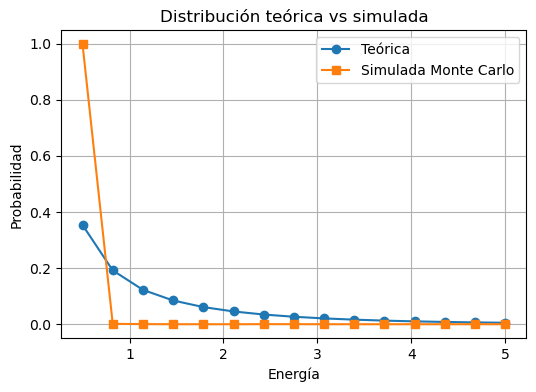

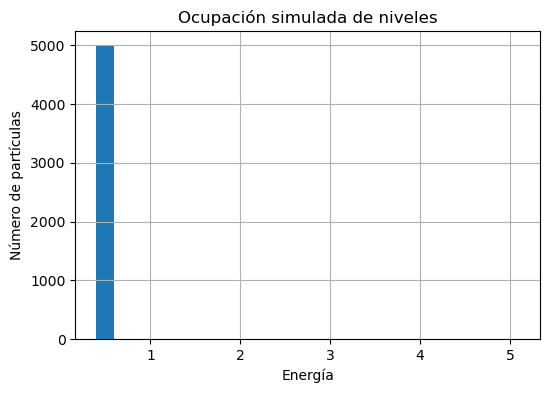

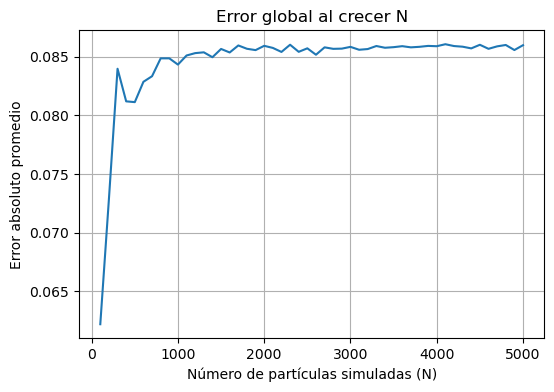

In [63]:
import numpy as np
import matplotlib.pyplot as plt

def distribucion_bose(cajas, T, mu=0.0, k=1.0):
    pesos = 1 / (np.exp((cajas - mu) / (k * T)) - 1)
    return pesos / np.sum(pesos)

def montecarlo_bose_simple(N, cajas, T, pasos, k=1.0):
    M = len(cajas)

    # Todas las partículas empiezan en el nivel más bajo
    ocupaciones = np.zeros(M, dtype=int)
    ocupaciones[0] = N

    for _ in range(pasos):
        # Elegir un origen ocupado
        origenes_posibles = np.where(ocupaciones > 0)[0]
        origen = np.random.choice(origenes_posibles)

        # Elegir un destino distinto
        destino = np.random.randint(M)
        while destino == origen:
            destino = np.random.randint(M)

        deltaE = cajas[destino] - cajas[origen]

        # Regla de Metropolis
        if deltaE <= 0 or np.random.rand() < np.exp(-deltaE / T):
            ocupaciones[origen] -= 1
            ocupaciones[destino] += 1

    # Convertimos ocupaciones a probabilidades simuladas
    prob_simulada = ocupaciones / N
    return ocupaciones, prob_simulada

def error_global(prob_simulada, prob_teorica):
    return np.mean(np.abs(prob_simulada - prob_teorica))


#Parámetros
cajas = np.linspace(0.5, 5.0, 15)
T = 1.5
mu = 0.0

prob_teorica = distribucion_bose(cajas, T, mu)

Ns = range(100, 5001, 100)
errores_mc = []

# Error al crecer N
for N in Ns:
    pasos = 20 * N   # más ligero que antes
    _, prob_simulada = montecarlo_bose_simple(N, cajas, T, pasos)
    errores_mc.append(error_global(prob_simulada, prob_teorica))

#Simulación final
N_final = 5000
pasos_finales = 20 * N_final
ocupaciones, prob_simulada = montecarlo_bose_simple(N_final, cajas, T, pasos_finales)

# Gráfica 1: teoría vs simulación
plt.figure(figsize=(6, 4))
plt.plot(cajas, prob_teorica, marker='o', label='Teórica')
plt.plot(cajas, prob_simulada, marker='s', label='Simulada Monte Carlo')
plt.xlabel("Energía")
plt.ylabel("Probabilidad")
plt.title("Distribución teórica vs simulada")
plt.grid(True)
plt.legend()
plt.show()

# Gráfica 2: histograma de ocupación
plt.figure(figsize=(6, 4))
plt.bar(cajas, ocupaciones, width=0.2)
plt.xlabel("Energía")
plt.ylabel("Número de partículas")
plt.title("Ocupación simulada de niveles")
plt.grid(True)
plt.show()

# Gráfica 3: error al crecer N
plt.figure(figsize=(6, 4))
plt.plot(list(Ns), errores_mc)
plt.xlabel("Número de partículas simuladas (N)")
plt.ylabel("Error absoluto promedio")
plt.title("Error global al crecer N")
plt.grid(True)
plt.show()

### Ventajas y desventajas de cada método


 #### 1. Método directo por probabilidades

$Ventajas$

1) Más simple de programar,

2) Más rápido computacionalmente,

3) Más estable,

4) El error suele bajar más limpiamente

$Desentajas$

1) No muestra evolución del sistema,

2) No modela dinámica,

3) Parte de la distribución final como dato de entrada,

4) Menos útil si quieres estudiar procesos de relajación o equilibrio.



####  2. Método Monte Carlo


$Ventajas$

1) Muestra una evolución estocástica real del sistema,

2) Permite hablar de equilibrio, transiciones y aceptación/rechazo,

3) Es más cercano a técnicas modernas de física estadística,

4) Sirve para enseñar procesos aleatorios dinámicos.

$Desventajas$

1) Es más lento,

2) necesita suficientes pasos para converger,

3) El error puede verse más ruidoso,

4) epende de dos escalas N y número de pasos.

## Distribución Fermi-Dirac

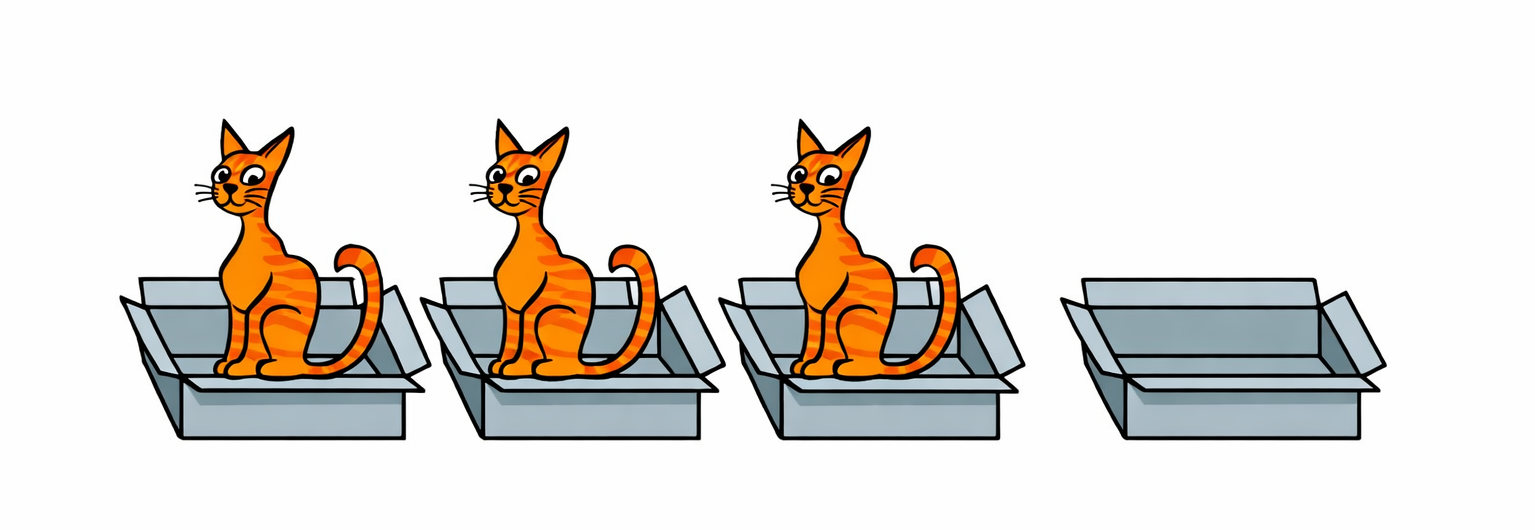

Fermi–Dirac cada caja puede tener a lo más una partícula. Esto a profundidas es el $$\textbf{"Principio de exclusión de Pauli"}$$

La distribución de Fermi-Dirac para la ocupación media de un estado de energía $\epsilon$ es

$$
f(\epsilon)=\frac{1}{e^{(\epsilon-\mu) /(k T)}+1}
$$

donde:
- e: energía del estado,
- T: temperatura,
- k: constante de Boltzmann,
- $\mu$ : potencial químico.

$\large Ojito$

- Si la energía es baja $\Rightarrow$ el estado tiene alta probabilidad de estar ocupado.

- Si la energía es alta $\Rightarrow$ la probabilidad de ocupación disminuye.

- Si la temperatura es baja $\Rightarrow$ la transición entre ocupados y vacíos es más brusca.
     Si T es MUY muy pequeña, la gráfica se parece a un escalón y por debajo de cierto umbral, los estados están casi ocupados, por encima, están casi vacíos.


- Si la temperatura es alta $\Rightarrow$ la transición se suaviza.

Curiosamente en esta distribucción, cada estado puede estar solo en dos posibilidades:
- vacío,
- ocupado.

Entonces para cada nivel podemos pensar en una variable aleatoria:

$$
X_i= \begin{cases}1, & \text { si el estado } i \text { está ocupado } \\ 0, & \text { si el estado } i \text { está vacío }\end{cases}
$$

y la probabilidad de ocupación es

$$
P\left(X_i=1\right)=f\left(\epsilon_i\right)
$$


Eso lo vuelve muy natural desde probabilidad, porque cada nivel se parece a una Bernoulli.

#### Pseudo código

In [ ]:
Definir función fermi_dirac(energias, T, mu, k):
    crear lista vacía probabilidades

    para cada energía e en energias:
        calcular x = (e - mu) / (k*T)
        calcular f = 1 / (exp(x) + 1)
        agregar f a la lista probabilidades

    regresar probabilidades como arreglo

Definir lista de energías
Definir temperatura T
Definir potencial químico mu

Calcular ocupacion = fermi_dirac(energias, T, mu)

Graficar energía contra ocupación
Etiquetar ejes y título
Mostrar gráfica

### Versión base

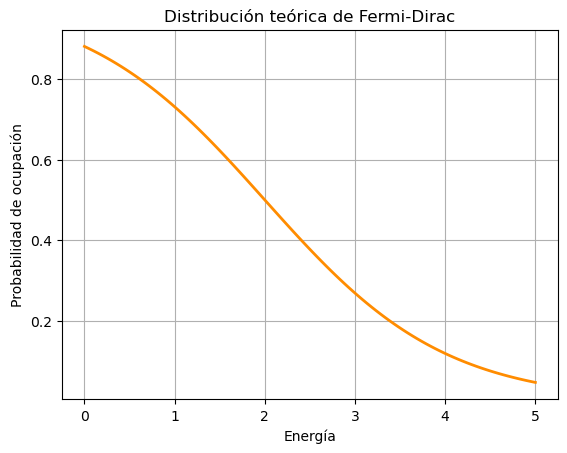

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def fermi_dirac(energias, T, mu=0.0, k=1.0):
    probabilidades = []
    for e in energias:
        x = (e - mu) / (k * T)
        f = 1 / (np.exp(x) + 1)
        probabilidades.append(f)
    return np.array(probabilidades)

energias = np.linspace(0, 5, 100)
T = 1.0
mu = 2.0

ocupacion = fermi_dirac(energias, T, mu)

plt.plot(energias, ocupacion, c ="darkorange", lw=2)
plt.xlabel("Energía")
plt.ylabel("Probabilidad de ocupación")
plt.title("Distribución teórica de Fermi-Dirac")
plt.grid(True)
plt.show()

### Simulación ocupación de estados

#### Pseudo código

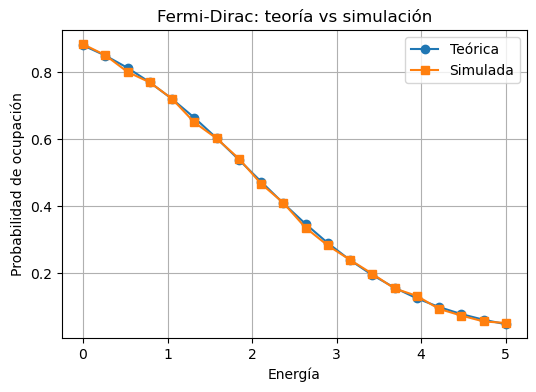

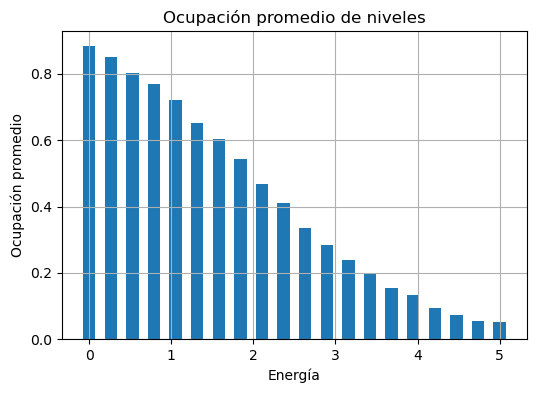

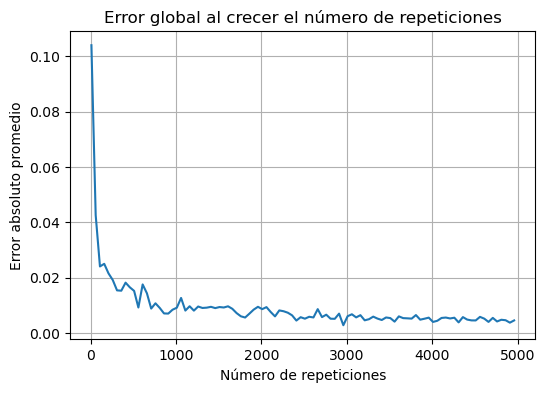

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def distribucion_fermi(cajas, T, mu=0.0, k=1.0):
    return 1 / (np.exp((cajas - mu) / (k * T)) + 1)

def simular_fermi_promedio(cajas, T, repeticiones, mu=0.0, k=1.0):
    prob_teorica = distribucion_fermi(cajas, T, mu, k)
    acumulado = np.zeros(len(cajas))

    for _ in range(repeticiones):
        aleatorios = np.random.rand(len(cajas))
        ocupaciones = (aleatorios < prob_teorica).astype(int)
        acumulado += ocupaciones

    promedio_ocup = acumulado / repeticiones
    return prob_teorica, promedio_ocup

def error_global(prob_simulada, prob_teorica):
    return np.mean(np.abs(prob_simulada - prob_teorica))

# Parámetros
cajas = np.linspace(0, 5, 20)
T = 1.0
mu = 2.0

# Error¡ 
Ns = range(10, 5001, 50)
errores = []

for N in Ns:
    prob_teorica, promedio_ocup = simular_fermi_promedio(cajas, T, N, mu)
    errores.append(error_global(promedio_ocup, prob_teorica))

# Simulación final
N_final = 5000
prob_teorica, promedio_ocup = simular_fermi_promedio(cajas, T, N_final, mu)

# Gráfica 1
plt.figure(figsize=(6,4))
plt.plot(cajas, prob_teorica, marker='o', label='Teórica')
plt.plot(cajas, promedio_ocup, marker='s', label='Simulada')
plt.xlabel("Energía")
plt.ylabel("Probabilidad de ocupación")
plt.title("Fermi-Dirac: teoría vs simulación")
plt.grid(True)
plt.legend()
plt.show()

# Gráfica 2
plt.figure(figsize=(6,4))
plt.bar(cajas, promedio_ocup, width=0.15)
plt.xlabel("Energía")
plt.ylabel("Ocupación promedio")
plt.title("Ocupación promedio de niveles")
plt.grid(True)
plt.show()

# Gráfica 3
plt.figure(figsize=(6,4))
plt.plot(list(Ns), errores)
plt.xlabel("Número de repeticiones")
plt.ylabel("Error absoluto promedio")
plt.title("Error global al crecer el número de repeticiones")
plt.grid(True)
plt.show()

Podemos repetir muchas veces el experimento y en cada repetición cada caja puede salir ocupada o vacía, usando su probabilidad Fermi–Dirac.

Luego promediamos ocupaciones.

### Método directo

Para cada nivel de energía calculamos la probabilidad de ocupación según Fermi–Dirac. Después generamos un número aleatorio entre 0 y 1. Si ese número es menor que la probabilidad, consideramos que el estado está ocupado; en caso contrario, queda vacío. Así simulamos una configuración posible del sistema, donde cada estado solo puede tener ocupación 0 o 1.

#### Pseudo código

In [ ]:
Definir función fermi_dirac(energias, T, mu, k):
    Para cada energía en energias:
        calcular probabilidad = 1 / (exp((energia - mu)/(k*T)) + 1)
    regresar lista de probabilidades

Definir función simular_fermi(energias, T, mu, k):
    calcular probabilidades usando fermi_dirac

    generar una lista de números aleatorios entre 0 y 1
    del mismo tamaño que energias

    para cada nivel i:
        si aleatorio_i < probabilidad_i:
            ocupacion_i = 1
        si no:
            ocupacion_i = 0

    regresar probabilidades y ocupaciones

Definir energías
Definir T y mu

Ejecutar simular_fermi
Graficar energía contra ocupación simulada


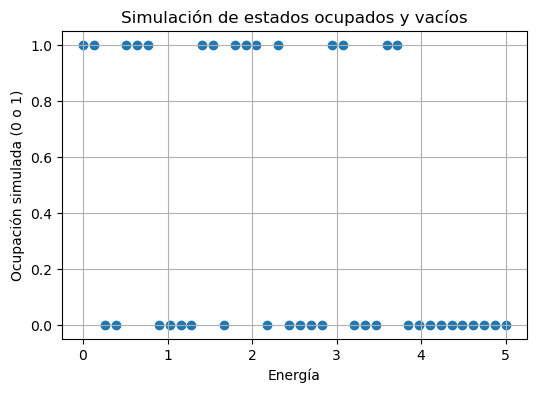

In [64]:
import numpy as np
import matplotlib.pyplot as plt

def fermi_dirac(energias, T, mu=0.0, k=1.0):
    return 1 / (np.exp((energias - mu) / (k * T)) + 1)

def simular_fermi(energias, T, mu=0.0, k=1.0):
    probabilidades = fermi_dirac(energias, T, mu, k)
    aleatorios = np.random.rand(len(energias))
    ocupacion = (aleatorios < probabilidades).astype(int)
    return probabilidades, ocupacion

# Parámetros
energias = np.linspace(0, 5, 40)
T = 1.0
mu = 2.0

probabilidades, ocupacion = simular_fermi(energias, T, mu)

plt.figure(figsize=(6,4))
plt.scatter(energias, ocupacion)
plt.xlabel("Energía")
plt.ylabel("Ocupación simulada (0 o 1)")
plt.title("Simulación de estados ocupados y vacíos")
plt.grid(True)
plt.show()

## Distribución de Boltzmann

La distribución de Boltzmann describe cómo se reparte la probabilidad entre distintos estados de energía cuando:

1) Los estados tienen diferentes energías,

3) Los estados de menor energía son más probables,

4) La temperatura controla qué tan dispersa está la distribución.

La fórmula básica es:

$$
P\left(\epsilon_i\right)=\frac{e^{-\epsilon_i /(k T)}}{Z}
$$

Aquí:
- $\epsilon_i$ : energía del estado $i_{\text {, }}$
- T: temperatura,
- $k$ : constante de Boltzmann,
- Z: constante de normalización, llamada función de partición,

$$
Z=\sum_i e^{-\epsilon_i /(k T)}
$$

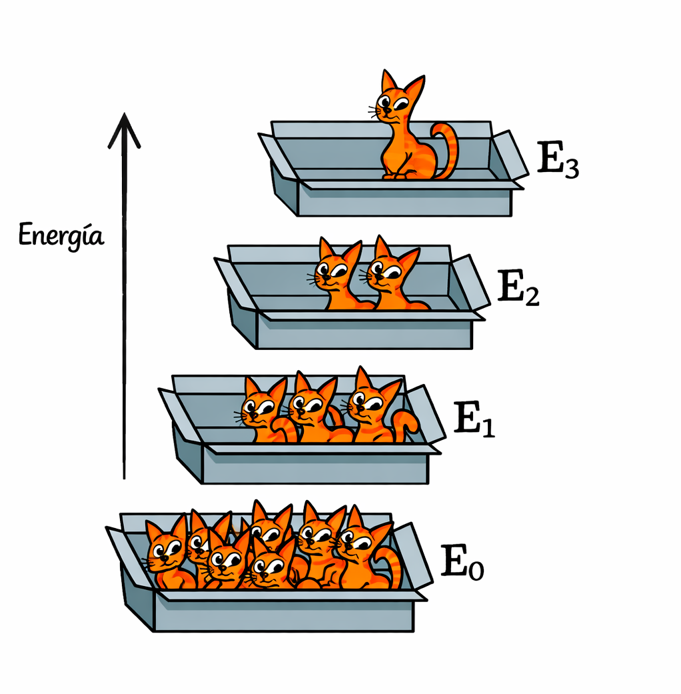

Si una partícula puede estar en varios estados, la probabilidad de encontrarla en el estado $i$ es proporcional a:
$$e^{-\epsilon_i /(k T)}$$.

Entonces:
- estados de baja energía $\Rightarrow$ mayor probabilidad,
- estados de alta energía $\Rightarrow$ menor probabilidad.

Imaginemos que los gatos se quieren colar en varias cajas con distintos "costos energéticos".

- entrar a una caja barata es más fácil,
- entrar a una caja cara es menos probable.

La distribución de Boltzmann asigna más probabilidad a las cajas baratas y menos a las caras.

En comparación con Fermi–Dirac da una probabilidad de ocupación con restricción (1 gato por caja), Boltzmann da una probabilidad clásica normalizada a partir de pesos.

# Versión base

Definir función boltzmann(energias, T, k):
    crear lista vacía pesos

    para cada energía e en energias:
        calcular peso = exp(-e / (k*T))
        guardar peso en pesos

    convertir pesos en arreglo
    calcular probabilidades = pesos / suma(pesos)

    regresar probabilidades

Definir lista de energías
Definir temperatura T

Calcular probabilidades con la función boltzmann

Graficar energía vs probabilidad
Mostrar la gráfica

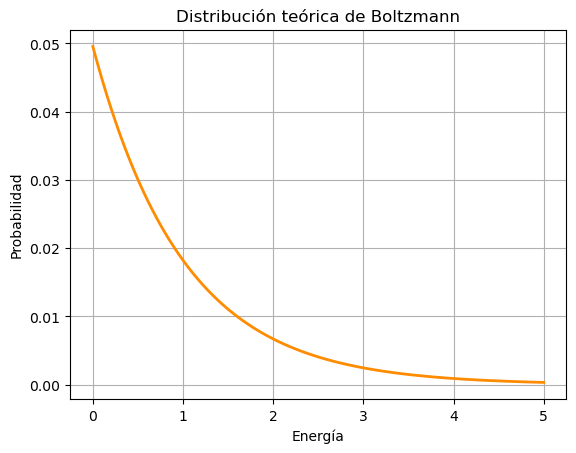

In [66]:
import numpy as np
import matplotlib.pyplot as plt

def boltzmann(energias, T, k=1.0):
    pesos = []
    
    for e in energias:
        w = np.exp(-e / (k * T))
        pesos.append(w)
    
    pesos = np.array(pesos)
    probabilidades = pesos / np.sum(pesos)
    
    return probabilidades

energias = np.linspace(0, 5, 100)
T = 1.0

probabilidades = boltzmann(energias, T)

plt.plot(energias, probabilidades, c="darkorange", lw=2)
plt.xlabel("Energía")
plt.ylabel("Probabilidad")
plt.title("Distribución teórica de Boltzmann")
plt.grid(True)
plt.show()

### Simulación

Supongamos que un gato puede estar en varias cajas:

$$
E_0, E_1, \ldots, E_{M-1}
$$


Queremos simular cómo cambia de caja con el tiempo, de modo que después de muchos pasos visite las cajass con frecuencias compatibles con Boltzmann.

La distribución teórica (forma explicita y completa) es:

$$
P\left(E_i\right)=\frac{e^{-E_i /(k T)}}{\sum_j e^{-E_j /(k T)}}
$$


Entonces, la idea de la simulación es:
1) Comenzar en un estado inicial,
2) Proponer saltos aleatorios a otros estados,
3) Aceptar o rechazar esos saltos con una regla probabilística.

Recordando Metropolis:

Si el gato está en una caja $E_i$ y proponemos moverla a una $E_j$, definimos este cambio:

$$
\Delta E=E_j-E_i
$$


Entonces:
- si $\Delta E \leq 0$, aceptamos siempre;
- si $\boldsymbol{\Delta} \boldsymbol{E}>0$, aceptamos con probabilidad

$$
e^{-\Delta E /(k T)}
$$


$\large{\text{¿Qué hace?}}?$

- Bajar energía es favorable,
- Subir energía se permite, pero menos frecuentemente,
- A mayor temperatura, más fácil subir.


Después de muchos pasos vamos a contar cuántas veces la partícula visita cada nivel para después construir frecuencias relativas, y comprar esasfrecuencias con la distribución de Boltzmann.

#### Pseudo Código

Definir función boltzmann_teorica(energias, T, k):
    para cada energía E_i:
        calcular peso_i = exp(-E_i/(k*T))
    normalizar pesos
    regresar probabilidades teóricas

Definir función metropolis_boltzmann(energias, T, pasos, k):
    elegir un estado inicial
    crear contador de visitas con ceros

    repetir "pasos" veces:
        proponer un nuevo estado aleatorio
        calcular deltaE = energia_nueva - energia_actual

        si deltaE <= 0:
            aceptar cambio
        si deltaE > 0:
            generar número aleatorio r
            aceptar si r < exp(-deltaE/(k*T))

        si se acepta:
            actualizar estado actual

        sumar una visita al estado actual

    convertir visitas en frecuencias
    regresar frecuencias

Definir energías, temperatura y número de pasos
Calcular distribución teórica
Ejecutar simulación Monte Carlo
Comparar frecuencias simuladas con probabilidades teóricas
Graficar resultados

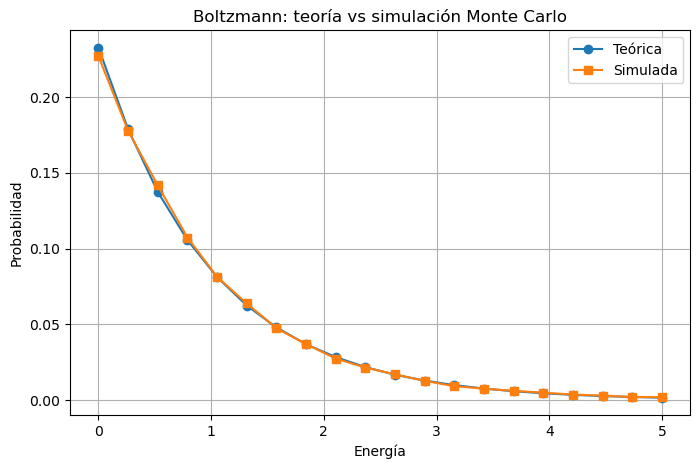

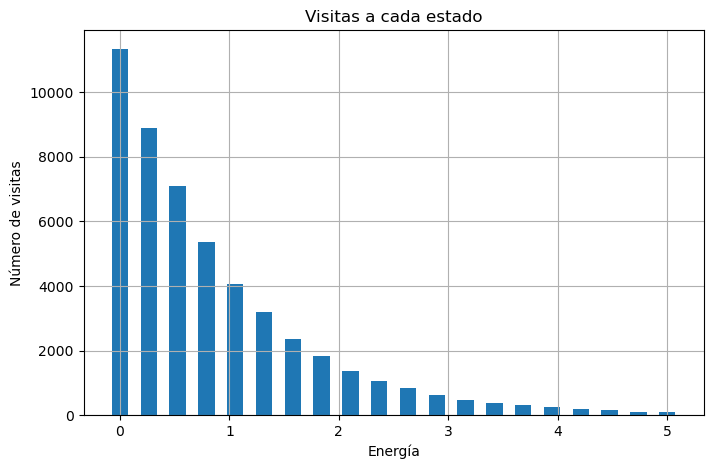

In [68]:
import numpy as np
import matplotlib.pyplot as plt

def boltzmann_teorica(energias, T, k=1.0):
    pesos = np.exp(-energias / (k * T))
    return pesos / np.sum(pesos)

def metropolis_boltzmann(energias, T, pasos, k=1.0):
    M = len(energias)

    # Empezamos en el estado de menor energía
    estado_actual = 0

    visitas = np.zeros(M, dtype=int)

    for _ in range(pasos):
        # Proponer un nuevo estado aleatorio
        estado_nuevo = np.random.randint(0, M)

        deltaE = energias[estado_nuevo] - energias[estado_actual]

        # Regla de Metropolis
        if deltaE <= 0 or np.random.rand() < np.exp(-deltaE / (k * T)):
            estado_actual = estado_nuevo

        # Contamos la visita al estado actual
        visitas[estado_actual] += 1

    frecuencias = visitas / np.sum(visitas)
    return frecuencias, visitas

# Parámetros
energias = np.linspace(0, 5, 20)
T = 1.0
pasos = 50000

prob_teorica = boltzmann_teorica(energias, T)
prob_simulada, visitas = metropolis_boltzmann(energias, T, pasos)

# Gráfica 1: teoría vs simulación
plt.figure(figsize=(8,5))
plt.plot(energias, prob_teorica, marker='o', label='Teórica')
plt.plot(energias, prob_simulada, marker='s', label='Simulada')
plt.xlabel("Energía")
plt.ylabel("Probabilidad")
plt.title("Boltzmann: teoría vs simulación Monte Carlo")
plt.grid(True)
plt.legend()
plt.show()

# Gráfica 2: histograma de visitas
plt.figure(figsize=(8,5))
plt.bar(energias, visitas, width=0.15)
plt.xlabel("Energía")
plt.ylabel("Número de visitas")
plt.title("Visitas a cada estado")
plt.grid(True)
plt.show()

### Ejemplos númericos

#### Para Bose-Einstein

Supón que tenemos cinco niveles de energía:

$$
\epsilon=[1,2,3,4,5]
$$

y elegimos, para simplificar:

$$
\mu=0, \quad k=1, \quad T=2
$$


La fórmula de Bose-Einstein es:

$$
n(\epsilon)=\frac{1}{e^{(\epsilon-\mu) /(k T)}-1}
$$


Como $\mu=0$ y $k=1$, queda:

$$
n(\epsilon)=\frac{1}{e^{\epsilon / 2}-1}
$$


Paso 1. Calcular cada ocupación
Para $\epsilon=1$

$$
n(1)=\frac{1}{e^{1 / 2}-1}
$$


Como

$$
e^{0.5} \approx 1.6487
$$

entonces

$$
n(1)=\frac{1}{1.6487-1}=\frac{1}{0.6487} \approx 1.54
$$

Para $\epsilon=2$

$$
n(2)=\frac{1}{e^1-1}
$$


Como

$$
e^1 \approx 2.7183
$$

entonces

$$
n(2)=\frac{1}{2.7183-1}=\frac{1}{1.7183} \approx 0.58
$$


Para $\epsilon=3$

$$
n(3)=\frac{1}{e^{1.5}-1}
$$


Como

$$
e^{1.5} \approx 4.4817
$$

entonces

$$
n(3)=\frac{1}{4.4817-1}=\frac{1}{3.4817} \approx 0.29
$$


Para $\epsilon=4$

$$
n(4)=\frac{1}{e^2-1}
$$


Como

$$
e^2 \approx 7.3891
$$

Entonces: 
$$
n(4)=\frac{1}{7.3891-1}=\frac{1}{6.3891} \approx 0.16
$$


Para $\epsilon=5$

$$
n(5)=\frac{1}{e^{2.5}-1}
$$


Como

$$
e^{2.5} \approx 12.1825
$$

entonces

$$
n(5)=\frac{1}{12.1825-1}=\frac{1}{11.1825} \approx 0.089
$$


Resumiendo:

In [36]:
import pandas as pd

# Datos de la tabla
data = {
    'epsilon': [1, 2, 3, 4, 5],
    'n(epsilon)': [1.54, 0.58, 0.29, 0.16, 0.089]
}

# Crear DataFrame
df = pd.DataFrame(data)

# Mostrar la tabla
print(df)

   epsilon  n(epsilon)
0        1       1.540
1        2       0.580
2        3       0.290
3        4       0.160
4        5       0.089


Esto significa que: el nivel de energía más bajo tiene la mayor ocupación promedio,

conforme aumenta la energía, la ocupación disminuye, en Bose–Einstein pueden aparecer ocupaciones mayores que 1, como en el caso de 
 $\epsilon=1$.

Ese último punto es muy importante, porque contrasta con Fermi–Dirac, donde la ocupación nunca puede superar 1.

#### Para Fermi-Dirac

Supón niveles:

$$
\epsilon=[0,1,2,3,4]
$$

y toma:

$$
\mu=2, \quad k=1, \quad T=1
$$


Entonces:

$$
f(\epsilon)=\frac{1}{e^{(\epsilon-2)}+1}
$$


Calculamos:
- para $\epsilon=0$ :

$$
f(0) \approx 0.88
$$

- para $\epsilon=1$ :

$$
f(1) \approx 0.73
$$

- para $\epsilon=2$ :

$$
f(2)=0.5
$$

- para $\epsilon=3$ :

$$
f(3) \approx 0.27
$$

- para $\epsilon=4$ :

$$
f(4) \approx 0.12
$$


Resumiendo:

In [50]:
import pandas as pd

data = {
    'epsilon': [1, 2, 3, 4, 5],
    'f(epsilon)': [0.88, 0.73, 0.50, 0.27, 0.12]
}

df = pd.DataFrame(data)

df1 = df.style \
    .format({'f(epsilon)': '{:.2f}'}) \
    .hide(axis='index') \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('padding', '6px'), ('text-align', 'center')]}
    ])
df1

epsilon,f(epsilon)
1,0.88
2,0.73
3,0.50
4,0.27
5,0.12


Esto quiere decir que: 
- Los niveles bajos casi siempre están ocupados,
- Los altos suelen estar vacíos.

#### Para Boltzmann

Tomemos cinco niveles de energía:

$$
\epsilon=[0,1,2,3,4]
$$

Elijamos, para simplificar:

$$
k=1, \quad T=1
$$


Entonces la probabilidad de cada nivel es proporcional a:

$$
e^{-\epsilon}
$$


Calculamos los pesos


$$
w_i=e^{-\epsilon_i}
$$


Entonces:
- para $\epsilon=0$ :

$$
w_0=e^0=1
$$

- para $\epsilon=1$ :

$$
w_1=e^{-1} \approx 0.3679
$$

- para $\epsilon=2$ :

$$
w_2=e^{-2} \approx 0.1353
$$

- para $\epsilon=3$ :

$$
w_3=e^{-3} \approx 0.0498
$$

- para $\epsilon=4$ :

$$
w_4=e^{-4} \approx 0.0183
$$

Por otra parte, sumamos los pesos

$$
\begin{gathered}
Z=1+0.3679+0.1353+0.0498+0.0183 \\
Z \approx 1.5713
\end{gathered}
$$


Normalizando:

$$
P\left(\epsilon_i\right)=\frac{w_i}{Z}
$$


Entonces:
$\cdot \epsilon=\mathbf{0}$ :

$$
P(0)=\frac{1}{1.5713} \approx 0.636
$$

- $\epsilon=1$ :

$$
P(1)=\frac{0.3679}{1.5713} \approx 0.234
$$

- $\epsilon=2$ :

$$
P(2)=\frac{0.1353}{1.5713} \approx 0.086
$$

- $\epsilon=3$ :

$$
P(3)=\frac{0.0498}{1.5713} \approx 0.032
$$

- $\epsilon=4$ :

$$
P(4)=\frac{0.0183}{1.5713} \approx 0.012
$$

In [62]:
data = {
    'epsilon': [1, 2, 3, 4, 5],
    'f(epsilon)': [0.636, 0.234, 0.086, 0.032, 0.012]
}

df = pd.DataFrame(data)

df1 = df.style \
    .format({'f(epsilon)': '{:.3f}'}) \
    .hide(axis='index') \
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', 'hotpink'), ('color', 'white'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('padding', '6px'), ('text-align', 'center')]}
    ])
df1

epsilon,f(epsilon)
1,0.636
2,0.234
3,0.086
4,0.032
5,0.012


Sumando todo:

$Boltzmann$

* Da la probabilidad de estar en un estado,

* No impone restricción de ocupación cuántica,

* Es la versión clásica.

$Fermi–Dirac$

* Cada estado puede estar ocupado o vacío,

* Ocupación máxima 1.

$Bose–Einstein$

* Varias partículas pueden compartir estado,

* Permite acumulación.